In [1]:
# Imports 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from pathlib import Path
import seaborn as sns

import matplotlib as mpl


import networkx as nx
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from vizman import viz
viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

from src.visualization.one_simple_plot import plot_one_aesthetic_plot

from scipy.stats import entropy
# from skimage.measure import shannon_entropy

In [2]:
# Colors 

lecker_red = default_colors["warms"]["LECKER_RED"]
bone_white = default_colors["neutrals"]["BONE_WHITE"]
olive_gray = default_colors["neutrals"]["OLIVE_GRAY"]
halfblack = default_colors["neutrals"]["HALF_BLACK"]

# get the colors for -1 and 1
cmap = default_cmaps["db_bw_lr"].resampled(2)
color_neg1 = cmap(0)
color_pos1 = cmap(1)

black_white_map = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_black_white', 
        [
            bone_white,
            "black",
         ]
    )

In [3]:
# dataset_name = "lexis_data" # "suarez_MaMI_dataset"
# experiment_name = "05_mst_animal_0" # 02_ring_sweeps_animal_0" # 05_mst_animal_0" # 

dataset_name = "hcp_schaefer_100_dataset" # lexis_data" # "suarez_MaMI_dataset"
experiment_name = "105_distance_metrics_mst_animal_0" # 05_mst_animal_0" # 02_ring_sweeps_animal_0" # 05_mst_animal_0" # 


# experiment_name = "02_ring_sweeps_animal_0" # "01_ring_sweep_animal_0" # "95_ring_seed_100_sweep_animal_206"
# experiment_name = "03_no_ring_sweeps_animal_0"
base_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}")
save_path = base_path / f"all_metrics_for_{experiment_name}.csv"


filtering_df_path = base_path / f"all_metrics_for_{experiment_name}.csv" # _updated.csv"
filtering_df = pd.read_csv(filtering_df_path)

output_path = Path(base_path) / "ground_truth_analysis"
output_path.mkdir(exist_ok=True)

In [4]:
# Get the name of all measures
all_dist_measures = [
    "energy", 
    "portrait", 
    "spectral_distance_adjacency",
    # "spectral_distance_norm_laplacian", 
    
    # "communicability_corr",
    # "communicability_jsd",
    # "network_mutual_information",
    # "dc_network_mutual_information", 
    
    "net_simile", 
    "netrd_non_backtracking_spectral", 
    "resistance", 
    "delta_con", 
    
    # "f1", 
    # "hamming",
    "frobenius", 
    # "jaccard", 
]

# # Color id 
# color_ids = {
#     "energy": 1, 
#     "portrait": 3, 
#     "spectral_distance_adjacency": 13,
#     # "spectral_distance_norm_laplacian": 4,

#     # "communicability_corr": 5,
#     # "communicability_jsd": 6,
#     # "network_mutual_information": 7,
#     # "dc_network_mutual_information": 8,

#     "net_simile": 4,
#     "netrd_non_backtracking_spectral": 12,
#     "resistance": 8,
#     "delta_con": 14,

#     # "f1": 13,
#     # "hamming": 14,
#     "frobenius": 7,
#     # "jaccard": 16,
# }



metric_colors = {'communicability_corr': (0.6, 0.6, 0.6),
                'dc_network_mutual_information': (0.9686274509803922,
                0.5058823529411764,
                0.7490196078431373),
                'network_mutual_information': (0.6509803921568628,
                0.33725490196078434,
                0.1568627450980392),
                'f1': (1.0, 0.4980392156862745, 0.0),
                'jaccard': (0.596078431372549, 0.3058823529411765, 0.6392156862745098),
                'communicability_jsd': (0.30196078431372547,
                0.6862745098039216,
                0.2901960784313726),
                'netrd_non_backtracking_spectral': (0.21568627450980393,
                0.49411764705882355,
                0.7215686274509804),
                'resistance': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
                'delta_con': (0.4, 0.4, 0.4),
                'hamming': (0.6509803921568628, 0.4627450980392157, 0.11372549019607843),
                'frobenius': (0.9019607843137255, 0.6705882352941176, 0.00784313725490196),
                'net_simile': (0.4, 0.6509803921568628, 0.11764705882352941),
                'spectral_distance_adjacency': (0.9058823529411765,
                0.1607843137254902,
                0.5411764705882353),
                'spectral_distance_norm_laplacian': (0.4588235294117647,
                0.4392156862745098,
                0.7019607843137254),
                'energy': (0.8509803921568627, 0.37254901960784315, 0.00784313725490196),
                'portrait': (0.10588235294117647, 0.6196078431372549, 0.4666666666666667)}





In [5]:

method_names = {
    'portrait': 'Portrait', #  Divergence',
    'energy': 'Energy', #  Distance',
        'spectral_distance': 'Spectral Distance', # Different versions?? 
    'spectral_distance_laplacian': 'Spectral (Laplacian)',
    'spectral_distance_norm_laplacian': 'Spectral (Normalized Laplacian)',
    'spectral_distance_adjacency': 'Spectral (Adjacency)',
    'f1': 'F1', #  Score',
    'hamming': 'Hamming', # Distance',
        'communicability': 'Communicability Correlation', #  Distance',
        'graph_kernel': 'Graph Kernel Distance old',
        'multiplex_layer_similarity': 'Multiplex Layer Similarity',
    'cosine_embedding': 'Cosine Embedding', #  Distance',
    'graph_edit_distance': 'Graph Edit', #  Distance',
    'network_mutual_information': 'Network Mutual Information',
    'dc_network_mutual_information': 'DC Network Mutual Information',
        'hungarian_alignment': 'Hungarian Alignment',
    'graph_kernel_networkx': 'Graph Kernel', #  Distance',
    'delta_con': 'DeltaCon',
    'delta_con_distance': 'DeltaCon (distance)', # Distance',
        'resistance_distance': 'Resistance old', #  Distance',
        'wasserstein_gromov': 'Wasserstein-Gromov Distance',
    'wasserstein_sinkhorn': 'Wasserstein-Sinkhorn', #  Distance',

        'edit_distance': 'Edit Distance old',
    'communicability_corr': 'Communicability Correlation',
    'communicability_mse': 'Communicability MSE',
    'communicability_jsd': 'Communicability JSD',
    'frobenius': 'Frobenius', #  Distance',
    'jaccard': 'Jaccard', #  Distance',

    'resistance': 'Resistance', #  Distance',
    'net_simile': 'NetSimile', #  Distance',
    # 'net_smile': 'NetSimile', #  Distance', # !!!! Typo, remove this later (after 05 it should be fixed)
    'net_lsd': 'NetLSD', #  Distance',
    'quantum_jsd': 'Quantum JSD', #  Distance',
    'graph_diffusion': 'Graph Diffusion', #  Distance',
    'polynomial_dissimilarity': 'Polynomial Dissimilarity', #  Distance',
    'degree_divergence': 'Degree Divergence', #  Distance',
    'onion_divergence': 'Onion Divergence', #  Distance',

    "network_mutual_information_old": "Network Mutual Information old",
    "netrd_deltacon": "NetRD DeltaCon",
    "netrd_communicability_jsd": "NetRD Communicability JSD",
    "distributional_nbd": "Distributional NBD",
    "dk_series": "DK Series",
    "d_measure": "D Measure",
    "netrd_frobenius": "NetRD Frobenius",
    "netrd_hamming": "NetRD Hamming",
    "hamming_ipsen_mikhailov": "Hamming Ipsen-Mikhailov",
    "ipsen_mikhailov": "Ipsen-Mikhailov",
    "netrd_jaccard": "NetRD Jaccard",
    "netrd_laplacian_spectral": "NetRD Laplacian Spectral",
    "netrd_non_backtracking_spectral": "Spectral (Non-Backtracking)", # NetRD Non-Backtracking Spectral",
    "netrd_portrait_divergence": "NetRD Portrait Divergence",
}


In [6]:
# Get values for every measure

matrices_of_metrics = {}

for idx, mode in enumerate(all_dist_measures):

    path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    df_further_measures = pd.read_csv(path)
    
    # Get the metric column
    metric_col = [col for col in df_further_measures.columns if col not in ["eta", "gamma", "network_index", "filename", "id"]]
    if not metric_col:
        raise ValueError(f"No metric column found in {df.columns}")
    
    # Round eta and gamma to a reasonable number of decimal places (e.g., 2 or 3)
    df_further_measures['eta'] = df_further_measures['eta'].round(2)
    df_further_measures['gamma'] = df_further_measures['gamma'].round(2)
    filtering_df['eta'] = filtering_df['eta'].round(2)
    filtering_df['gamma'] = filtering_df['gamma'].round(2)

    # Now merge
    if "no" in experiment_name: # FILTER BY NUMBER COMPONENTS. Alternative: not "ring" in experiment_name:
        df_further_measures = df_further_measures.merge(filtering_df[['eta', 'gamma', 'n_connected_components']], 
                    on=['eta', 'gamma'], 
                    how='left')
        # Filter
        df_further_measures = df_further_measures[df_further_measures['n_connected_components'] <= 1]
    
    else: 
        df_further_measures = df_further_measures.merge(filtering_df[['eta', 'gamma']], 
                    on=['eta', 'gamma'], 
                    how='left')



    # Turn df into a pivot table. If there are multiple values for one eta-gamma pair, take the mean
    df_pivot = df_further_measures.pivot_table(index='gamma', columns='eta', values=metric_col[0], aggfunc='mean')

    # Min-max normalize the values to [0, 1]
    df_pivot = (df_pivot - df_pivot.min().min()) / (df_pivot.max().max() - df_pivot.min().min())
    
    # Store the matrix as a numpy array
    matrix = df_pivot.values[::-1]
    if mode in ["f1", 
                "multiplex_layer_similarity", 
                "jaccard", 
                # "communicability_jsd", 
                "communicability_corr",
                "network_mutual_information", 
                "dc_network_mutual_information", 
            ]: # TODO: WHICH OTHER SIMILARITY METRICS? 
        matrix = 1 - matrix  # Invert for similarity measures

    # if mode == "resistance":
    #     matrix = np.log1p(matrix)  # Apply log1p transformation
        
    matrices_of_metrics[mode] = matrix


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/4056359108.py:5: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(matrices_of_metrics[m]), cmap='viridis')


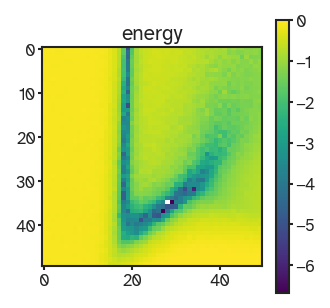

In [7]:
measures = all_dist_measures

for m in measures: 
    plt.figure(figsize=viz.cm_to_inch((6,6)), dpi=150)
    plt.imshow(np.log(matrices_of_metrics[m]), cmap='viridis')
    plt.colorbar()
    plt.title(m)
    plt.show()
    break

# Other stuff

In [8]:
# Functions: Correlation matrix, clustering, reordering
def load_method_data(method):
    """Load data for a specific method."""
    path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
    try:
        df = pd.read_csv(path)
        metric_cols = [col for col in df.columns 
                      if col not in ["eta", "gamma", "network_index", "filename", "id"]]
        if metric_cols:
            df['metric_value'] = df[metric_cols[0]]
            df['method'] = method
            return df[['eta', 'gamma', 'id', 'metric_value', 'method']]
        return None
    except FileNotFoundError:
        print(f"Warning: File not found for method {method}")
        return None

def calculate_ground_truth(all_data):
    """Calculate approximated ground truth as max across methods for each eta-gamma-id."""
    ground_truth = all_data.groupby(['eta', 'gamma', 'id'])['metric_value'].max().reset_index()
    ground_truth.rename(columns={'metric_value': 'approximated_ground_truth'}, inplace=True)
    return ground_truth

def create_full_dataset(all_data, ground_truth):
    """Create dataset with all methods and ground truth."""
    pivot_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    if ground_truth is not None:
        full_data = pivot_data.merge(ground_truth, on=['eta', 'gamma', 'id'])
    else: 
        full_data = pivot_data
    return full_data

def calculate_correlation_matrix(full_data, methods):
    """Calculate Pearson correlation matrix between methods and ground truth."""
    cols_to_correlate = methods # + ['approximated_ground_truth']
    corr_matrix = full_data[cols_to_correlate].corr(method='pearson')
    return corr_matrix

def cluster_correlation_matrix(corr_matrix):
    """
    Cluster the correlation matrix using hierarchical clustering.
    Returns the reordered correlation matrix and the order of items.
    """
    # Convert correlation to distance
    # Use 1 - correlation for positive correlations (closer to 1 = more similar)
    distance_matrix = 1 - corr_matrix.values
    
    # Ensure all values are non-negative and clip to avoid numerical issues
    distance_matrix = np.clip(distance_matrix, 0, 2)
    
    # Make sure the matrix is symmetric
    distance_matrix = (distance_matrix + distance_matrix.T) / 2
    
    # Set diagonal to 0
    np.fill_diagonal(distance_matrix, 0)
    
    # Convert to condensed distance matrix
    condensed_dist = squareform(distance_matrix, checks=False)
    
    # Replace any NaN or inf values
    condensed_dist = np.nan_to_num(condensed_dist, nan=1.0, posinf=2.0, neginf=0.0)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method='average')  # Changed to 'average' which is more robust
    
    # Get the order from the dendrogram
    dendro = dendrogram(linkage_matrix, no_plot=True)
    order = dendro['leaves']

    # Reorder the correlation matrix
    ordered_corr = corr_matrix.iloc[order, order]
    
    return ordered_corr, order, linkage_matrix


In [9]:
print("Loading method data...")
all_data_list = []
loaded_methods = []

for method in all_dist_measures:
    df = load_method_data(method)
    if df is not None:
        all_data_list.append(df)
        loaded_methods.append(method)
        print(f"Loaded {method}: {len(df)} rows")
    
all_data = pd.concat(all_data_list, ignore_index=True)

full_data = create_full_dataset(all_data, ground_truth=None)
corr_matrix = calculate_correlation_matrix(full_data, loaded_methods)

corr_path = output_path / 'correlation_matrix.csv'
corr_matrix.to_csv(corr_path)


# Cluster the correlation matrix
clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)

# Reorder all_methods based on clustering
all_dist_measures = [all_dist_measures[i] for i in order]  

Loading method data...
Loaded energy: 25000 rows
Loaded portrait: 25000 rows
Loaded spectral_distance_adjacency: 25000 rows
Loaded net_simile: 25000 rows
Loaded netrd_non_backtracking_spectral: 25000 rows
Loaded resistance: 25000 rows
Loaded delta_con: 25000 rows
Loaded frobenius: 25000 rows


# Further grid plots

In [10]:
# Functions: Visual Quality Analyzation 
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, uniform_filter
from skimage.metrics import structural_similarity as ssim
from skimage.measure import shannon_entropy
import pandas as pd

class VisualQualityAnalyzer:
    """Analyze visual quality and structure of similarity matrices"""
    
    def __init__(self, matrix):
        self.matrix = np.array(matrix, dtype=float)
        
    def calculate_gradient_smoothness(self):
        """Lower = smoother gradients, less noisy"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        # Variation in gradients indicates noise
        smoothness_score = np.std(grad_y) + np.std(grad_x)
        return smoothness_score
    
    def calculate_total_variation(self):
        """Total variation - lower = smoother"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        tv = np.sum(np.abs(grad_y)) + np.sum(np.abs(grad_x[:, :-1]))
        return tv / self.matrix.size
    
    def calculate_local_coherence(self, window_size=3):
        """Higher = more locally coherent"""
        local_mean = uniform_filter(self.matrix, size=window_size)
        local_sq_mean = uniform_filter(self.matrix**2, size=window_size)
        local_var = local_sq_mean - local_mean**2
        
        # Avoid division by zero
        coherence = 1 / (np.mean(local_var) + 1e-10)
        return coherence
    
    def calculate_snr(self, sigma=2):
        """Signal-to-noise ratio - higher = clearer structure"""
        smoothed = gaussian_filter(self.matrix, sigma=sigma)
        noise = self.matrix - smoothed
        
        signal_power = np.var(smoothed)
        noise_power = np.var(noise)
        
        if noise_power < 1e-10:
            return 100
        
        snr = 10 * np.log10(signal_power / noise_power)
        return snr
    
    def calculate_structure_similarity(self, sigma=5):
        """Similarity to ideal smooth version - higher = better"""
        ideal = gaussian_filter(self.matrix, sigma=sigma)
        
        data_range = self.matrix.max() - self.matrix.min()
        if data_range < 1e-10:
            return 0
            
        score = ssim(self.matrix, ideal, data_range=data_range)
        return score
    
    def calculate_entropy(self):
        """Shannon entropy - for reference"""
        return shannon_entropy(self.matrix)
    
    def calculate_contrast(self):
        """Dynamic range"""
        return self.matrix.max() - self.matrix.min()
    
    def calculate_edge_strength(self):
        """Measure edge clarity using Sobel-like gradients"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        # Pad to same size
        grad_y = np.pad(grad_y, ((0, 1), (0, 0)), mode='edge')
        grad_x = np.pad(grad_x, ((0, 0), (0, 1)), mode='edge')
        
        # Gradient magnitude
        grad_magnitude = np.sqrt(grad_y**2 + grad_x**2)
        return np.mean(grad_magnitude)
    
    def get_all_metrics(self):
        """Calculate all quality metrics"""
        return {
            'entropy': self.calculate_entropy(),
            'gradient_smoothness': self.calculate_gradient_smoothness(),
            'total_variation': self.calculate_total_variation(),
            'local_coherence': self.calculate_local_coherence(),
            'snr': self.calculate_snr(),
            'structure_similarity': self.calculate_structure_similarity(),
            'contrast': self.calculate_contrast(),
            'edge_strength': self.calculate_edge_strength()
        }
    
    def calculate_composite_quality(self):
        """
        Composite quality score emphasizing visual structure
        Higher = better visual quality
        """
        metrics = self.get_all_metrics()
        
        # Normalize and combine (weights tuned for visual quality)
        score = (
            metrics['snr'] * 0.25 +  # High SNR = clear structure
            metrics['structure_similarity'] * 50 * 0.25 +  # Similar to smooth ideal
            (1 / (metrics['gradient_smoothness'] + 0.1)) * 0.20 +  # Smooth gradients
            metrics['local_coherence'] * 0.15 +  # Locally coherent
            (1 / (metrics['total_variation'] + 0.01)) * 0.15  # Low total variation
        )
        
        return score


def analyze_all_methods(matrices_dict, nan_strategy='mean'):
    """Analyze all similarity methods"""
    results = {}
    
    for name, matrix in matrices_dict.items():
        matrix = matrix.copy()
        
        # Handle NaNs
        if np.isnan(matrix).any():
            if nan_strategy == 'mean':
                matrix = np.nan_to_num(matrix, nan=np.nanmean(matrix))
            elif nan_strategy == 'zero':
                matrix = np.nan_to_num(matrix, nan=0)
            elif nan_strategy == 'interpolate':
                # Simple interpolation
                mask = np.isnan(matrix)
                matrix[mask] = np.interp(np.flatnonzero(mask), 
                                        np.flatnonzero(~mask), 
                                        matrix[~mask])
        
        # min max normalize the matrix
        matrix = (matrix - matrix.min()) / (matrix.max() - matrix.min())
        analyzer = VisualQualityAnalyzer(matrix)
        results[name] = analyzer.get_all_metrics()
        results[name]['composite_quality'] = analyzer.calculate_composite_quality()
    
    return pd.DataFrame(results).T

def plot_comprehensive_comparison(results_df, metric_colors=None):
    """Plot all metrics for comparison"""
    
    # Metrics to plot
    metrics = [
        'entropy', 'gradient_smoothness', 'total_variation', 'local_coherence',
        'snr', 'structure_similarity', 'contrast', 'composite_quality'
    ]
    
    # Better interpretation labels
    labels = {
        'entropy': 'Entropy\n(lower = more structure)',
        'gradient_smoothness': 'Gradient Smoothness\n(lower = less noisy)',
        'total_variation': 'Total Variation\n(lower = smoother)',
        'local_coherence': 'Local Coherence\n(higher = better)',
        'snr': 'Signal-to-Noise Ratio\n(higher = better)',
        'structure_similarity': 'Structure Similarity\n(higher = better)',
        'contrast': 'Contrast\n(higher = better)',
        'composite_quality': 'Composite Quality Score\n(higher = BETTER)'
    }
    
    # Create subplots
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # Sort by metric value for better visualization
        sorted_data = results_df[metric].sort_values()
        
        # Get colors if provided
        if metric_colors:
            colors = [metric_colors.get(name, 'gray') for name in sorted_data.index]
        else:
            colors = 'steelblue'
        
        ax.barh(range(len(sorted_data)), sorted_data.values, color=colors)
        ax.set_yticks(range(len(sorted_data)))
        ax.set_yticklabels(sorted_data.index, fontsize=8)
        ax.set_xlabel(labels.get(metric, metric))
        ax.set_title(metric.replace('_', ' ').title())
        ax.grid(axis='x', alpha=0.3)
    
    # Remove empty subplot
    fig.delaxes(axes[-1])
    
    plt.tight_layout()
    # plt.show()
    
    return fig


def rank_methods(results_df, metric='composite_quality'):
    """Rank methods by a specific metric"""
    ranked = results_df.sort_values(metric, ascending=False)
    
    print(f"\n{'='*70}")
    print(f"RANKING BY: {metric.upper()}")
    print(f"{'='*70}")
    print(f"{'Rank':<6} {'Method':<30} {'Score':>10}")
    print(f"{'-'*70}")
    
    for idx, (method, row) in enumerate(ranked.iterrows(), 1):
        print(f"{idx:<6} {method:<30} {row[metric]:>10.4f}")
    
    print(f"{'='*70}\n")
    
    return ranked

In [11]:
# results_df = analyze_all_methods(matrices_of_metrics)
# print(results_df.round(4))

# # # get indices of "ranked" in its ascending order of "snr"
# # snr_ranked_indices = results_df['snr'].sort_values(ascending=False).index.tolist()

# # metric_colors = {}
# # colors = sns.color_palette("tab20", 16)

# # for i, metric_name in enumerate(snr_ranked_indices):
# #         metric_colors[metric_name] = colors[color_ids[metric_name]]

# Further selection metrics 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, uniform_filter
from skimage.metrics import structural_similarity as ssim
from skimage.measure import shannon_entropy
import pandas as pd

class VisualQualityAnalyzer:
    """Analyze visual quality and structure of similarity matrices"""
    
    def __init__(self, matrix, mask=None):
        self.matrix = np.array(matrix, dtype=float)
        self.mask = mask
        
    def calculate_gradient_smoothness(self):
        """Lower = smoother gradients, less noisy"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)

        # # Apply mask if provided - but how? 
        # if self.mask is not None:
        #     grad_y = grad_y[self.mask[:-1, :]]
        #     grad_x = grad_x[:, self.mask[:-1]]

        # Variation in gradients indicates noise
        smoothness_score = np.std(grad_y) + np.std(grad_x)
        return smoothness_score
    
    def calculate_total_variation(self):
        """Total variation - lower = smoother"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)

        # Apply mask if provided - but how? 
        # grad_y = grad_y[self.mask[:-1, :]]
        # grad_x = grad_x[:, self.mask[:-1]]

        tv = np.sum(np.abs(grad_y)) + np.sum(np.abs(grad_x[:, :-1]))
        return tv / self.matrix.size
    
    def calculate_local_coherence(self, window_size=3):
        """Higher = more locally coherent"""
        local_mean = uniform_filter(self.matrix, size=window_size)
        local_sq_mean = uniform_filter(self.matrix**2, size=window_size)
        local_var = local_sq_mean - local_mean**2
        
        local_var = local_var[self.mask]
        
        # Avoid division by zero
        coherence = 1 / (np.mean(local_var) + 1e-10)
        return coherence
    
    def calculate_snr(self, sigma=2):
        """Signal-to-noise ratio - higher = clearer structure"""
        smoothed = gaussian_filter(self.matrix, sigma=sigma)
        noise = self.matrix - smoothed
        
        # Remove all masked values (NaNs) from calculation
        smoothed = smoothed[self.mask]
        noise = noise[self.mask]

        signal_power = np.var(smoothed - np.mean(smoothed))
        noise_power = np.var(noise)
        
        if noise_power < 1e-10:
            return 100
        
        snr = 10 * np.log10(signal_power / noise_power)
        return snr
    
    def calculate_structure_similarity(self, sigma=5):
        """Similarity to ideal smooth version - higher = better"""
        ideal = gaussian_filter(self.matrix, sigma=sigma)
        
        data_range = self.matrix.max() - self.matrix.min()
        if data_range < 1e-10:
            return 0
            
        score = ssim(self.matrix, ideal, data_range=data_range)
        return score
    
    def calculate_entropy(self):
        """Shannon entropy - for reference"""
        return shannon_entropy(self.matrix)
    
    # def calculate_contrast(self):
    #     """Dynamic range"""
    #     return self.matrix.max() - self.matrix.min()
    
    def calculate_edge_strength(self):
        """Measure edge clarity using Sobel-like gradients"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        # Pad to same size
        grad_y = np.pad(grad_y, ((0, 1), (0, 0)), mode='edge')
        grad_x = np.pad(grad_x, ((0, 0), (0, 1)), mode='edge')
        
        # Gradient magnitude
        grad_magnitude = np.sqrt(grad_y**2 + grad_x**2)
        return np.mean(grad_magnitude)
    
    def get_all_metrics(self):
        """Calculate all quality metrics"""
        return {
            'entropy': self.calculate_entropy(),
            'gradient_smoothness': self.calculate_gradient_smoothness(),
            'total_variation': self.calculate_total_variation(),
            'local_coherence': self.calculate_local_coherence(),
            'snr': self.calculate_snr(),
            'structure_similarity': self.calculate_structure_similarity(),
            # 'contrast': self.calculate_contrast(),
            'edge_strength': self.calculate_edge_strength()
        }
    
    # def calculate_composite_quality(self):
    #     """
    #     Composite quality score emphasizing visual structure
    #     Higher = better visual quality
    #     """
    #     metrics = self.get_all_metrics()
        
    #     # Normalize and combine (weights tuned for visual quality)
    #     score = (
    #         metrics['snr'] * 0.25 +  # High SNR = clear structure
    #         metrics['structure_similarity'] * 50 * 0.25 +  # Similar to smooth ideal
    #         (1 / (metrics['gradient_smoothness'] + 0.1)) * 0.20 +  # Smooth gradients
    #         metrics['local_coherence'] * 0.15 +  # Locally coherent
    #         (1 / (metrics['total_variation'] + 0.01)) * 0.15  # Low total variation
    #     )
        
    #     return score


# def analyze_all_methods(matrices_dict):
#     """Analyze all similarity methods"""
#     results = {}
    
#     for name, matrix in matrices_dict.items():
        
#         # min max normalize the matrix
#         matrix = (matrix - matrix.min()) / (matrix.max() - matrix.min())
#         analyzer = VisualQualityAnalyzer(matrix)
#         results[name] = analyzer.get_all_metrics()
#         # results[name]['composite_quality'] = analyzer.calculate_composite_quality()
    
#     return pd.DataFrame(results).T

def analyze_all_methods(matrices_dict, nan_strategy='mean'):
    """Analyze all similarity methods"""
    results = {}
    
    for name, matrix in matrices_dict.items():
        matrix = matrix.copy()
        
        # Turn mask into a 0, 1 mask (from the current nan positions)
        mask = np.ones_like(matrix, dtype=bool)
        mask[np.isnan(matrix)] = False
        
        # Handle NaNs
        if np.isnan(matrix).any():
            if nan_strategy == 'mean':
                matrix = np.nan_to_num(matrix, nan=np.nanmean(matrix))
            elif nan_strategy == 'zero':
                matrix = np.nan_to_num(matrix, nan=0)
            elif nan_strategy == 'interpolate':
                # Simple interpolation
                mask = np.isnan(matrix)
                matrix[mask] = np.interp(np.flatnonzero(mask), 
                                        np.flatnonzero(~mask), 
                                        matrix[~mask])
        
        # min max normalize the matrix
        matrix = (matrix - matrix.min()) / (matrix.max() - matrix.min())
        analyzer = VisualQualityAnalyzer(matrix)
        results[name] = analyzer.get_all_metrics()
        # results[name]['composite_quality'] = analyzer.calculate_composite_quality()
    
    return pd.DataFrame(results).T



def rank_methods(results_df, metric='composite_quality'):
    """Rank methods by a specific metric"""
    ranked = results_df.sort_values(metric, ascending=False)
    
    print(f"\n{'='*70}")
    print(f"RANKING BY: {metric.upper()}")
    print(f"{'='*70}")
    print(f"{'Rank':<6} {'Method':<30} {'Score':>10}")
    print(f"{'-'*70}")
    
    for idx, (method, row) in enumerate(ranked.iterrows(), 1):
        print(f"{idx:<6} {method:<30} {row[metric]:>10.4f}")
    
    print(f"{'='*70}\n")
    
    return ranked



results_df = analyze_all_methods(matrices_of_metrics)

# Rank 
ranked = rank_methods(results_df, "snr") # , 'composite_quality')


RANKING BY: SNR
Rank   Method                              Score
----------------------------------------------------------------------
1      frobenius                         20.6603
2      resistance                        14.5776
3      energy                            14.1008
4      portrait                          13.0543
5      netrd_non_backtracking_spectral    13.0417
6      spectral_distance_adjacency       11.5060
7      net_simile                        11.0283
8      delta_con                         10.1630



# Continuing other stuff

In [13]:
selected_methods = [
    "energy",
    "portrait",
    "delta_con",
    "hamming",
    "frobenius",
    "spectral_distance_adjacency",
    # "spectral_distance_laplacian",
    "spectral_distance_norm_laplacian",
    "communicability_mse",
    "communicability_corr", 
    "communicability_jsd",
    "network_mutual_information",
    "dc_network_mutual_information",
    "net_lsd",
    "net_smile",
    "resistance",
    "quantum_jsd",
    # "delta_con_distance",
    # "f1",
    # "jaccard",
    # "graph_kernel_networkx",
    # "wasserstein_sinkhorn"
]

frobenius
net_simile
spectral_distance_adjacency
energy
portrait
delta_con
netrd_non_backtracking_spectral
resistance


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/2644309335.py:34: RuntimeWarning: divide by zero encountered in log
  scatter = ax.imshow(np.log(matrices_of_metrics[mode]), # matrices_of_metrics[mode],
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/2644309335.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/sixteen_similarity_plots_grayscale_log_with_x_eq_0.pdf


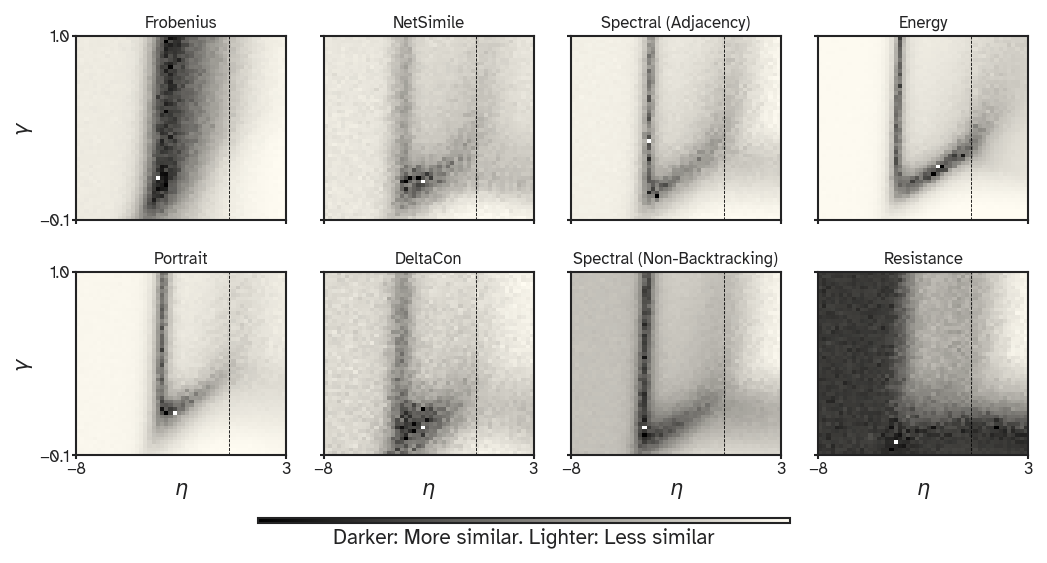

In [14]:

n_methods = len(all_dist_measures)
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

# Calculate height to maintain roughly square subplots
height = 18 * (n_rows / n_cols) # * 0.9 # 0.9 is random factor for colorbar

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((18, height)), 
                            dpi=150,
                            sharex=True, 
                            sharey=True)

axes = axes.flatten()

for idx, mode in enumerate(all_dist_measures):
    ax = axes[idx]
    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            # metric_colors[mode], 
            # "white", 
            bone_white
        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ]
    )
    # cmap = default_cmaps["metric_purple_beige"]

    scatter = ax.imshow(np.log(matrices_of_metrics[mode]), # matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
    ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])

    ax.vlines(x=0, 
              ymin=df["gamma"].min(), ymax=df["gamma"].max(), 
              color='black', linestyle='--', linewidth=0.4)
    
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # Only add labels to edge subplots
    if idx % n_cols == 0:  # Left column
        ax.set_ylabel(r"$\gamma$")
    if idx >= n_methods - n_cols:  # Bottom row
        ax.set_xlabel(r"$\eta$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

# Add one shared colorbar below all subplots
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
cbar.set_ticks([])  # Remove ticks
plt.tight_layout()

plt.savefig(output_path / "sixteen_similarity_plots_grayscale_log_with_x_eq_0.pdf", bbox_inches="tight")
print(output_path / "sixteen_similarity_plots_grayscale_log_with_x_eq_0.pdf")

In [15]:
selected_methods = all_dist_measures # ["energy", "spectral_distance", "portrait", "graph_kernel_networkx", "communicability_jsd", "delta_con"]


# Timing 

number dots: 25000
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/timing_comparison_top_8.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/1858717639.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(timing_data,


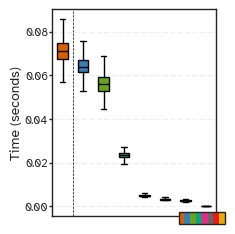

In [16]:
timing_data = []
method_labels = []
method_key_names_ordered = []

for method in selected_methods:
    # Construct the timing file path
    timing_file = Path(base_path) / f"timing_{method}_for_exp_{experiment_name}.csv"
    
    # Check if file exists
    if not timing_file.exists():
        print(f"Warning: File not found - {timing_file}")
        continue
    
    # Read timing data
    df = pd.read_csv(timing_file) # ALL dots! 
    # df = pd.read_csv(timing_file)[:2500]
    
    # Find the timing column
    timing_col = None
    for col in df.columns:
        if any(keyword in col.lower() for keyword in ['time']):
            timing_col = col
            break
    
    # Extract timing values
    timings = df[timing_col].dropna().values
    
    if len(timings) > 0:
        timing_data.append(timings)
        method_labels.append(method_names[method]) # .replace("_", " ").title())

# Order methods by median timing
# if order_by_median:
median_timings = [np.median(data) for data in timing_data]
sorted_indices = np.argsort(median_timings)[::-1]
timing_data = [timing_data[i] for i in sorted_indices]
method_labels = [method_labels[i] for i in sorted_indices]
method_key_names_ordered = [selected_methods[i] for i in sorted_indices]

print("number dots:", len(timing_data[0]))


# Create boxplot
fig = plt.figure(figsize=viz.cm_to_inch((6,6))) # (8, 8))

bp = plt.boxplot(timing_data, 
                labels=method_labels,
                patch_artist=True,
                showmeans=False, # True,
                showfliers=False, # True, # False, 
                ) 

# Customize appearance
for patch, color in zip(bp['boxes'], [metric_colors[method] for method in method_key_names_ordered]):
    patch.set_facecolor(color)


# Change median lines to black
for median in bp['medians']:
    median.set_color('black')


plt.ylabel('Time (seconds)') 
plt.xticks([]) 
# plt.xticks(rotation=90) 
# plt.yscale('log')
# # Add grid for better readability
plt.gca().yaxis.grid(True, alpha=0.3, linestyle='--')
# plt.gca().set_axisbelow(True)

# Add vertical line below the first 5 entries
plt.axvline(x=1.5, color='black', linewidth=0.5, linestyle='--')




# --- Colorbar-style legend ---------------------------------------------------

plt.tight_layout()

ax_pos = ax.get_position()

bar_height = 0.05
gap = 0.05 # 25 # 1

cax = fig.add_axes([
    ax_pos.x0, #  + 0.1, #  + 0.2, # 085, # - 0.005,
    ax_pos.y0 - bar_height - gap,
    ax_pos.width, #  - 0.12, # 0.04, # + 0.1,
    bar_height,
])

legend_colors = [metric_colors[m] for m in method_key_names_ordered]

cmap = mpl.colors.ListedColormap(legend_colors)
norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(len(legend_colors) + 1),
    ncolors=len(legend_colors),
)

scalar_mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
scalar_mappable.set_array([])

colorbar = fig.colorbar(
    scalar_mappable,
    cax=cax,
    orientation="horizontal",
)

# Hide all colorbar axes/ticks
colorbar.set_ticklabels([])
colorbar.ax.xaxis.set_visible(False)
colorbar.ax.yaxis.set_visible(False)




plt.savefig(output_path / "timing_comparison_top_8.pdf", bbox_inches="tight")
print(output_path / "timing_comparison_top_8.pdf")

In [17]:
timing_data = []
method_labels = []
method_key_names_ordered = []

for method in selected_methods:
    # Construct the timing file path
    timing_file = Path(base_path) / f"timing_{method}_for_exp_{experiment_name}.csv"
    
    # Check if file exists
    if not timing_file.exists():
        print(f"Warning: File not found - {timing_file}")
        continue
    
    # Read timing data
    df = pd.read_csv(timing_file) 
    print(df)

    
    
    data_list = []
    
    for method_name, t in zip(method_key_names_ordered, timing_data):
        df_temp = pd.DataFrame({
            'Time (seconds)': t,
            'Method': method_name
        })
        data_list.append(df_temp)


       network_index                                           filename  \
0                  0  net_eta1.653061270713806_gamma0.66326528787612...   
1                  1  net_eta-1.040816307067872_gamma0.0346938744187...   
2                  2  net_eta-7.775510311126709_gamma-0.100000001490...   
3                  3  net_eta-1.265306115150452_gamma0.5285714268684...   
4                  4  net_eta-4.18367338180542_gamma0.21428570151329...   
...              ...                                                ...   
24995          24995  net_eta-3.061224460601807_gamma-0.010204084217...   
24996          24996  net_eta0.530612289905548_gamma0.48367348313331...   
24997          24997  net_eta1.653061270713806_gamma0.50612246990203...   
24998          24998  net_eta-2.612245082855225_gamma0.6408163309097...   
24999          24999  net_eta-0.59183669090271_gamma0.37142854928970...   

            eta     gamma  id  time_subject_0_x  time_subject_0_y  
0      1.653061  0.663265   0  

In [18]:
timing_data = []
method_labels = []
method_key_names_ordered = []

for method in selected_methods:
    # Construct the timing file path
    timing_file = Path(base_path) / f"timing_{method}_for_exp_{experiment_name}.csv"
    
    # Check if file exists
    if not timing_file.exists():
        print(f"Warning: File not found - {timing_file}")
        continue
    
    # Read timing data
    df = pd.read_csv(timing_file) # ALL dots! 
    # df = pd.read_csv(timing_file)[:2500]
    
    # Find the timing column
    timing_col = None
    for col in df.columns:
        if any(keyword in col.lower() for keyword in ['time']):
            timing_col = col
            break
    
    # Extract timing values
    timings = df[timing_col].dropna().values
    
    if len(timings) > 0:
        timing_data.append(timings)
        method_labels.append(method_names[method]) # .replace("_", " ").title())

# Order methods by median timing
# if order_by_median:
median_timings = [np.median(data) for data in timing_data]
sorted_indices = np.argsort(median_timings)[::-1]
timing_data = [timing_data[i] for i in sorted_indices]
method_labels = [method_labels[i] for i in sorted_indices]
method_key_names_ordered = [selected_methods[i] for i in sorted_indices]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/2958790371.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/2958790371.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/2958790371.py:37: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/timing_8_with_violin_and_scatter.png
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/timing_8_with_violin_and_scatter.pdf


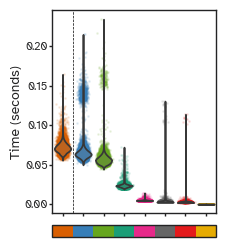

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl

# Prepare data for seaborn: convert list of arrays to a long-form DataFrame
# timing_data: list of arrays, one per method
# method_key_names_ordered: list of method names in the same order
data_list = []
for method_name, t in zip(method_key_names_ordered, timing_data):
    df_temp = pd.DataFrame({
        'Time (seconds)': t,
        'Method': method_name
    })
    data_list.append(df_temp)

df = pd.concat(data_list, ignore_index=True)

# Create figure
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)))  # assuming viz.cm_to_inch is just scaling, skip for now

# Optional: overlay scatter with jitter like in your original code
for i, method in enumerate(method_key_names_ordered):
    t = timing_data[i]
    jitter = np.random.normal(loc=0, scale=0.1, size=len(t))
    ax.scatter(
        np.ones_like(t) * i + jitter,
        t,
        c=metric_colors[method], 
        s=1,
        alpha=0.1,
        # color='black'
    )
    
# Violin plot
sns.violinplot(
    x='Method',
    y='Time (seconds)',
    data=df,
    palette=metric_colors,  # dict of {method_name: color}
    cut=0,
    scale='width',
    inner=None,
    ax=ax
)

# Y-axis log scale
# ax.set_yscale('log')

# Remove x-ticks labels if desired
ax.set_xticklabels([])
ax.set_xlabel(None)

ax.set_ylabel('Time (seconds)')


# Add vertical line below the first 5 entries
ax.axvline(x=0.5, color='black', linewidth=0.5, linestyle='--')



# # --- Horizontal colorbar like in your original code ---
# pos = ax.get_position()
# bar_height = 0.03
# gap = 0.1

# cax = fig.add_axes([
#     pos.x0 - 0.005,
#     pos.y0 - bar_height - gap,
#     pos.width + 0.075,
#     bar_height
# ])

# colors_for_legend = [metric_colors[m] for m in method_key_names_ordered]

# cmap = mpl.colors.ListedColormap(colors_for_legend)
# norm = mpl.colors.BoundaryNorm(
#     boundaries=np.arange(len(colors_for_legend) + 1),
#     ncolors=len(colors_for_legend)
# )

# sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
# cb.set_ticklabels([])
# cb.ax.yaxis.set_visible(False)
# cb.ax.xaxis.set_visible(False)


plt.tight_layout()

# --- Colorbar-style legend ---------------------------------------------------
ax_pos = ax.get_position()

bar_height = 0.05
gap = 0.05 # 25 # 1

cax = fig.add_axes([
    ax_pos.x0, #  + 0.19, #  + 0.2, # 085, # - 0.005,
    ax_pos.y0 - bar_height - gap,
    ax_pos.width, #  - 0.18, # 0.04, # + 0.1,
    bar_height,
])

legend_colors = [metric_colors[m] for m in method_key_names_ordered]

cmap = mpl.colors.ListedColormap(legend_colors)
norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(len(legend_colors) + 1),
    ncolors=len(legend_colors),
)

scalar_mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
scalar_mappable.set_array([])

colorbar = fig.colorbar(
    scalar_mappable,
    cax=cax,
    orientation="horizontal",
)

# Hide all colorbar axes/ticks
colorbar.set_ticklabels([])
colorbar.ax.xaxis.set_visible(False)
colorbar.ax.yaxis.set_visible(False)

plt.savefig(output_path / "timing_8_with_violin_and_scatter.png", dpi=450, bbox_inches="tight")
print(output_path / "timing_8_with_violin_and_scatter.png")
plt.savefig(output_path / "timing_8_with_violin_and_scatter.pdf", bbox_inches="tight")
print(output_path / "timing_8_with_violin_and_scatter.pdf")



/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/3489653294.py:148: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(np.ones_like(t) * i + jitter, t,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/3489653294.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/3489653294.py:152: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


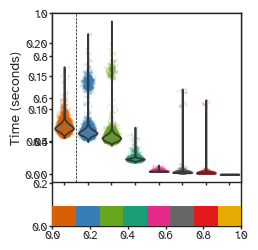

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl

# Prepare data for seaborn: convert list of arrays to a long-form DataFrame
# timing_data: list of arrays, one per method
# method_key_names_ordered: list of method names in the same order
data_list = []
for method_name, t in zip(method_key_names_ordered, timing_data):
    df_temp = pd.DataFrame({
        'Time (seconds)': t,
        'Method': method_name
    })
    data_list.append(df_temp)

df = pd.concat(data_list, ignore_index=True)

# # Create figure
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)))  # assuming viz.cm_to_inch is just scaling, skip for now

# # Optional: overlay scatter with jitter like in your original code
# for i, method in enumerate(method_key_names_ordered):
#     t = timing_data[i]
#     jitter = np.random.normal(loc=0, scale=0.1, size=len(t))
#     ax.scatter(
#         np.ones_like(t) * i + jitter,
#         t,
#         c=metric_colors[method], 
#         s=1,
#         alpha=0.1,
#         # color='black'
#     )
    
# # Violin plot
# sns.violinplot(
#     x='Method',
#     y='Time (seconds)',
#     data=df,
#     palette=metric_colors,  # dict of {method_name: color}
#     cut=0,
#     scale='width',
#     inner=None,
#     ax=ax
# )

# # Y-axis log scale
# # ax.set_yscale('log')

# # Remove x-ticks labels if desired
# ax.set_xticklabels([])
# ax.set_xlabel(None)

# ax.set_ylabel('Time (seconds)')


# # Add vertical line below the first 5 entries
# ax.axvline(x=0.5, color='black', linewidth=0.5, linestyle='--')



# # # --- Horizontal colorbar like in your original code ---
# # pos = ax.get_position()
# # bar_height = 0.03
# # gap = 0.1

# # cax = fig.add_axes([
# #     pos.x0 - 0.005,
# #     pos.y0 - bar_height - gap,
# #     pos.width + 0.075,
# #     bar_height
# # ])

# # colors_for_legend = [metric_colors[m] for m in method_key_names_ordered]

# # cmap = mpl.colors.ListedColormap(colors_for_legend)
# # norm = mpl.colors.BoundaryNorm(
# #     boundaries=np.arange(len(colors_for_legend) + 1),
# #     ncolors=len(colors_for_legend)
# # )

# # sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
# # sm.set_array([])

# # cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
# # cb.set_ticklabels([])
# # cb.ax.yaxis.set_visible(False)
# # cb.ax.xaxis.set_visible(False)


# plt.tight_layout()

# # --- Colorbar-style legend ---------------------------------------------------
# ax_pos = ax.get_position()

# bar_height = 0.05
# gap = 0.05 # 25 # 1

# cax = fig.add_axes([
#     ax_pos.x0, #  + 0.19, #  + 0.2, # 085, # - 0.005,
#     ax_pos.y0 - bar_height - gap,
#     ax_pos.width, #  - 0.18, # 0.04, # + 0.1,
#     bar_height,
# ])

# legend_colors = [metric_colors[m] for m in method_key_names_ordered]

# cmap = mpl.colors.ListedColormap(legend_colors)
# norm = mpl.colors.BoundaryNorm(
#     boundaries=np.arange(len(legend_colors) + 1),
#     ncolors=len(legend_colors),
# )

# scalar_mappable = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
# scalar_mappable.set_array([])

# colorbar = fig.colorbar(
#     scalar_mappable,
#     cax=cax,
#     orientation="horizontal",
# )

# # Hide all colorbar axes/ticks
# colorbar.set_ticklabels([])
# colorbar.ax.xaxis.set_visible(False)
# colorbar.ax.yaxis.set_visible(False)

# plt.savefig(output_path / "timing_8_with_violin_and_scatter.png", dpi=450, bbox_inches="tight")
# print(output_path / "timing_8_with_violin_and_scatter.png")
# plt.savefig(output_path / "timing_8_with_violin_and_scatter.pdf", bbox_inches="tight")
# print(output_path / "timing_8_with_violin_and_scatter.pdf")

# fig = plt.figure(figsize=FIGSIZE_IN, dpi=DPI)
gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[1.0, 0.12],  # fixed colorbar height
    hspace=0.25,
)

ax = fig.add_subplot(gs[0])

# scatter
for i, method in enumerate(method_key_names_ordered):
    t = timing_data[i]
    jitter = np.random.normal(0, 0.1, size=len(t))
    ax.scatter(np.ones_like(t) * i + jitter, t,
               c=metric_colors[method], s=1, alpha=0.1)

# violin
sns.violinplot(
    x='Method',
    y='Time (seconds)',
    data=df,
    palette=metric_colors,
    cut=0,
    scale='width',
    inner=None,
    ax=ax
)

ax.set_xticklabels([])
ax.set_xlabel(None)
ax.set_ylabel("Time (seconds)")
ax.axvline(x=0.5, color='black', linewidth=0.5, linestyle='--')

# --- colorbar axis (fixed height, does NOT affect main axes)
cax = fig.add_subplot(gs[1])

legend_colors = [metric_colors[m] for m in method_key_names_ordered]
cmap = mpl.colors.ListedColormap(legend_colors)
norm = mpl.colors.BoundaryNorm(np.arange(len(legend_colors) + 1), len(legend_colors))

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.set_axis_off()

# 🔑 same margins as other plots
fig.subplots_adjust(left=0.18, right=0.98, top=0.98, bottom=0.08)

plt.savefig(output_path / "timing_8_with_violin_and_scatter.pdf")
plt.savefig(output_path / "timing_8_with_violin_and_scatter.png", dpi=450)



/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/537363430.py:27: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/537363430.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67816/537363430.py:37: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipyke

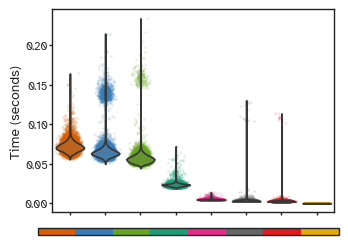

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl

# Prepare data for seaborn: convert list of arrays to a long-form DataFrame
# timing_data: list of arrays, one per method
# method_key_names_ordered: list of method names in the same order
data_list = []
for method_name, t in zip(method_key_names_ordered, timing_data):
    df_temp = pd.DataFrame({
        'Time (seconds)': t,
        'Method': method_name
    })
    data_list.append(df_temp)

df = pd.concat(data_list, ignore_index=True)

# Create figure
fig, ax = plt.subplots(figsize=viz.cm_to_inch((9, 6)))  # assuming viz.cm_to_inch is just scaling, skip for now

# Optional: overlay scatter with jitter like in your original code
for i, method in enumerate(method_key_names_ordered):
    t = timing_data[i]
    jitter = np.random.normal(loc=0, scale=0.1, size=len(t))
    ax.scatter(
        np.ones_like(t) * i + jitter,
        t,
        c=metric_colors[method], 
        s=1,
        alpha=0.1,
        # color='black'
    )
    
# Violin plot
sns.violinplot(
    x='Method',
    y='Time (seconds)',
    data=df,
    palette=metric_colors,  # dict of {method_name: color}
    cut=0,
    scale='width',
    inner=None,
    ax=ax
)

# Y-axis log scale
# ax.set_yscale('log')

# Remove x-ticks labels if desired
ax.set_xticklabels([])
ax.set_xlabel(None)

ax.set_ylabel('Time (seconds)')

# --- Horizontal colorbar like in your original code ---
pos = ax.get_position()
bar_height = 0.03
gap = 0.1

cax = fig.add_axes([
    pos.x0 - 0.005,
    pos.y0 - bar_height - gap,
    pos.width + 0.075,
    bar_height
])

colors_for_legend = [metric_colors[m] for m in method_key_names_ordered]

cmap = mpl.colors.ListedColormap(colors_for_legend)
norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(len(colors_for_legend) + 1),
    ncolors=len(colors_for_legend)
)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cb = fig.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_ticklabels([])
cb.ax.yaxis.set_visible(False)
cb.ax.xaxis.set_visible(False)

plt.tight_layout()
# plt.savefig(output_path / "timing_16_with_violin_and_scatter.png", bbox_inches="tight")
# print(output_path / "timing_16_with_violin_and_scatter.png")
# # plt.savefig(output_path / "timing_16_with_violin_and_scatter.pdf", bbox_inches="tight")
# # print(output_path / "timing_16_with_violin_and_scatter.pdf")


# Correlation Matrix 

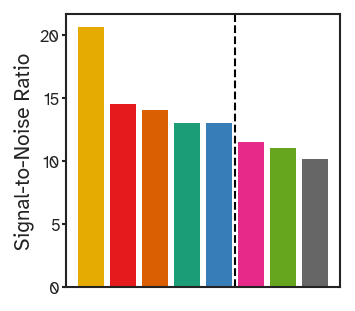

In [22]:
# BUILT FOR 16 networks! (mit plt und ohne subplot) 

def plot_comprehensive_comparison(results_df, metric_colors=None):

    """Plot all metrics for comparison"""
    metric = "snr"
    labels = {'snr': 'Signal-to-Noise Ratio'} # \n(higher = better)'}

    fig = plt.figure(figsize=viz.cm_to_inch((6,6)), dpi=150)
    # ax = fig.add_axes([0.15, 0.25, 0.7, 0.65])
    
    sorted_data = results_df[metric].sort_values()[::-1]
    colors = [metric_colors.get(name) for name in sorted_data.index]

    plt.bar(range(len(sorted_data)), sorted_data.values, color=colors)
    plt.xticks([])  # Remove y-axis ticks

    plt.ylabel(labels.get(metric, metric))
    # plt.title("SNR")
    plt.grid(axis='x', alpha=0.3)

    # Add vertical line below the first 5 entries
    plt.axvline(x=4.5, color='black', linestyle='--')

plot_comprehensive_comparison(results_df, metric_colors)

In [23]:
# all_methods_sorted_for_legend = [m for m in snr_ranked_indices if m in all_dist_measures]
# all_methods_sorted_for_legend = all_methods_sorted_for_legend[::-1]

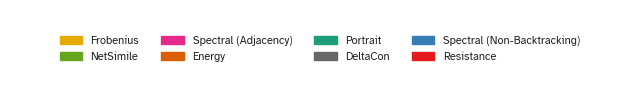

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/105_distance_metrics_mst_animal_0/ground_truth_analysis/method_legend_colored.pdf


In [24]:
fig = plt.figure(figsize=(8, 1))  # Adjust size as needed
ax = fig.add_subplot(111)

# sorted_data = results_df[metric].sort_values()

# Create legend handles
handles = [patches.Patch(color=metric_colors[name], label=method_names[name]) 
           for name in all_dist_measures] # [::-1]]

# Add legend
legend = ax.legend(handles=handles, loc='center', 
                   ncol=4, 
                #    fontsize=12, 
                   frameon=False)

# Hide the axes
ax.axis('off')

# plt.tight_layout()

plt.savefig(output_path / "method_legend_colored.pdf", bbox_inches="tight")
plt.show()
print(output_path / "method_legend_colored.pdf")

In [25]:
"""Plot all metrics for comparison"""

# Metrics to plot
metrics = [
    # 'entropy', 
    'snr', 
    'gradient_smoothness', 'total_variation', 'local_coherence',
    # 'structure_similarity', 
    # # 'contrast', 'composite_quality'
]

# Better interpretation labels
labels = {
    'entropy': 'Entropy\n(lower = more structure)',
    'gradient_smoothness': 'Gradient Smoothness\n(lower = less noisy)',
    'total_variation': 'Total Variation\n(lower = smoother)',
    'local_coherence': 'Local Coherence\n(higher = better)',
    'snr': 'Signal-to-Noise Ratio\n(higher = better)',
    'structure_similarity': 'Structure Similarity\n(higher = better)',
    'contrast': 'Contrast\n(higher = better)',
    # 'composite_quality': 'Composite Quality Score\n(higher = BETTER)'
}

lims = {
    # 'entropy': [0, 0.15],
    'gradient_smoothness': [0, 0.15], 
    'total_variation': [0, 0.1],
    'local_coherence': [0, 1200],
    'snr': [0, 15], # 'Signal-to-Noise Ratio\n(higher = better)',
    # 'structure_similarity': 'Structure Similarity\n(higher = better)',
    # 'contrast': 'Contrast\n(higher = better)',
    # 'composite_quality': 'Composite Quality Score\n(higher = BETTER)'
}
                       
results_df = results_df.loc[all_methods_sorted_for_legend[::-1]] # all_dist_measures]

# Create subplots
fig, axes = plt.subplots(1, 4, figsize=viz.cm_to_inch((18, 6)))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    sorted_data = results_df[metric]
    
    # Get colors if provided
    if metric_colors:
        colors = [metric_colors.get(name, 'gray') for name in sorted_data.index]
    else:
        colors = 'steelblue'
    
    ax.bar(range(len(sorted_data)), sorted_data.values, color=colors)
    ax.set_xticks([])
    # ax.set_yticks(lims[metric])
    # ax.set_yticks(range(len(sorted_data)))
    # ax.set_yticklabels([]) # sorted_data.index, fontsize=8)
    # ax.set_yticklabels(sorted_data.index, fontsize=8)
    
    # ax.set_ylabel(labels.get(metric, metric))
    ax.set_title(labels.get(metric, metric))
    
    # ax.set_title(metric.replace('_', ' ').title())
    # ax.grid(axis='x', alpha=0.3)

# Remove empty subplot
# fig.delaxes(axes[-1])
plt.tight_layout()

if output_path != "": 
    plt.savefig(output_path / "snr_entropy_vertical_etc.pdf", bbox_inches="tight")
    print(output_path / "snr_entropy_vertical_etc.pdf")
# plt.show()


NameError: name 'all_methods_sorted_for_legend' is not defined

In [ ]:
# def get_top_networks_distribution(dataset_name, experiment_name, mode='portrait', top_n=20):

#     # Paths
#     base_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}"
#     summary_path = f"{base_path}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
#     networks_path = f"{base_path}/generated_networks"
    
#     # Load summary data
#     df = pd.read_csv(summary_path)
#     # print(f"Loaded summary with columns: {list(df.columns)}")
    
#     # Identify metric column (excluding metadata columns)
#     metadata_cols = ["eta", "gamma", "network_index", "filename", "id"]
#     metric_cols = [col for col in df.columns if col not in metadata_cols]
    
#     if not metric_cols:
#         raise ValueError(f"No metric column found in {df.columns}")
    
#     metric_col = metric_cols[0]
#     print(f"Using metric column: '{metric_col}'")
    
#     # Select top N networks (lowest values = best)
#     df_sorted = df.nsmallest(top_n, metric_col)
#     # print(f"\nSelected top {top_n} networks with {metric_col} range: "
#     #       f"[{df_sorted[metric_col].min():.6f}, {df_sorted[metric_col].max():.6f}]")
        
#     # Load distance matrix (schaefer) 
#     distance_matrix_file = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy"
#     distance_matrix = np.load(distance_matrix_file)
    
    
#     # Load networks and calculate degree distributions
#     all_degrees = []
#     all_distances = []
    
#     etas = []
#     gammas = []
    
#     for idx, row in df_sorted.iterrows():
#         # Construct filename
#         network_file = Path(networks_path) / row['filename']
        
#         # Load network
#         network = np.load(network_file)
        
#         # Extract adjacency matrix (assuming shape is (1, 100, 100))
#         if network.shape[0] == 1:
#             adj_matrix = network[0]
#         else:
#             adj_matrix = network
        
#         # Calculate degree for each node
#         degrees = np.sum(adj_matrix, axis=1)
#         all_degrees.extend(degrees)
        
#         # get all distances, remove zeros 
#         distances_for_this_network = (distance_matrix*network).flatten()
#         all_distances.extend(distances_for_this_network[distances_for_this_network > 0])
        
#         etas.append(row['eta'])
#         gammas.append(row['gamma'])
        
#     # Convert to numpy array
#     all_degrees = np.array(all_degrees)
#     all_distances = np.array(all_distances)
#     etas = np.array(etas)
#     gammas = np.array(gammas)
#     # print(f"\nCollected {len(all_degrees)} node degrees from {len(df_sorted)} networks")
#     # print(f"Degree statistics: mean={all_degrees.mean():.2f}, "
#     #       f"std={all_degrees.std():.2f}, "
#     #       f"min={all_degrees.min()}, max={all_degrees.max()}")   

#     # Get distance matrix values (excluding zeros on diagonal)
#     # all_distances = distance_matrix[distance_matrix > 0]

#     return all_degrees, all_distances, etas, gammas

# distributions_degree = {}
# distributions_distances = {}
# distributions_etas = {}
# distributions_gammas = {}
# for mode in all_dist_measures: 
#     distributions_degree[mode], distributions_distances[mode], distributions_etas[mode], distributions_gammas[mode] = get_top_networks_distribution(dataset_name, experiment_name, mode=mode, top_n=20)


Using metric column: 'Resistance_subject_0'
Using metric column: 'DeltaCon_subject_0'
Using metric column: 'Frobenius_subject_0'
Using metric column: 'SpectralDist_adjacency_subject_0'
Using metric column: 'Netrd_non_backtracking_spectral_subject_0'
Using metric column: 'MaxCrit_subject_0'
Using metric column: 'PortraitDiv_subject_0'
Using metric column: 'Net_smile_subject_0'


0.009521033852939412
0.029603291727352418
0.04751353713755417
0.05626822401828474
0.06009996055411961
0.06636193460484253
0.09675447559198501
0.1091743030591676
[0.   0.02 0.04 0.06 0.08 0.1  0.12]
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/ground_truth_analysis/total_variation_of_minima.pdf


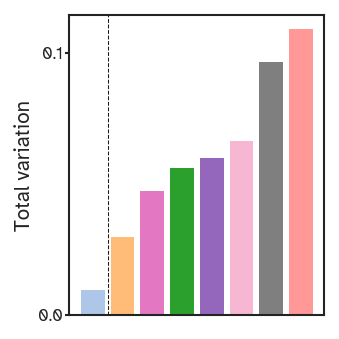

In [ ]:
plt.figure(figsize=viz.cm_to_inch((6, 6)), dpi=150)

eta_lim_min = np.inf 
eta_lim_max = -np.inf
gamma_lim_min = np.inf
gamma_lim_max = -np.inf

combined_variability = {}

for mode in all_dist_measures: 
    normalized_etas = (distributions_etas[mode] - (-3)) / (8 - (-3))
    normalized_gammas = (distributions_gammas[mode] - (-0.1)) / (1 - (-0.1))

    std_normalized_eta = normalized_etas.std()
    std_normalized_gamma = normalized_gammas.std()
    
    combined_var = std_normalized_eta**2 + std_normalized_gamma**2

    combined_variability[mode] = combined_var


# Sort 
for (mode, var) in sorted(combined_variability.items(), key=lambda kv: (kv[1], kv[0])): # reverse=True):
    print(var)
    plt.bar(mode, var, color=metric_colors[mode])
    
# plt.xticks(ticks=all_dist_measures, labels=[method_names[m] for m in all_dist_measures], rotation=90)
plt.xticks([])

# get current y-tick locations
y_ticks = plt.yticks()[0]
print(y_ticks)
# plt.yticks([y_ticks.min(), y_ticks.max()])
plt.yticks([0, 0.1])
plt.ylabel("Total variation") #  (lower = better)")

# TODO: Vertical line between the first and the remaining bars 
plt.axvline(x=0.5, linestyle="--", linewidth=0.5, color="k")

plt.tight_layout()
fig.subplots_adjust(left=0.18, right=0.98, bottom=0.18, top=0.98)

plt.savefig(output_path/ "total_variation_of_minima.pdf", bbox_inches="tight")
print(output_path / "total_variation_of_minima.pdf")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/ground_truth_analysis/minimums_for_top_8.pdf


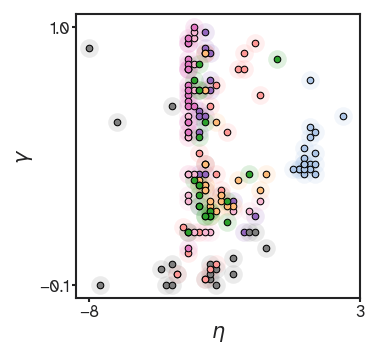

In [ ]:
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), dpi=150)

for mode in all_dist_measures:
    x = distributions_etas[mode]
    
    y = distributions_gammas[mode]
    c = metric_colors[mode]

    # --- blur / glow layer ---
    ax.scatter(
        x, y,
        color=c,
        s=80,          # much larger
        alpha=0.15,    # very transparent
        linewidth=0,
        zorder=1
    )
    # --- sharp dots on top ---
    ax.scatter(
        x, y,
        color=c,
        label=method_names[mode],
        s=10,
        edgecolor='black',
        linewidth=0.5,
        zorder=2
    )
    
plt.xticks([-8,3])
plt.yticks([-0.1,1])
plt.ylabel(r"$\gamma$")
plt.xlabel(r"$\eta$")

# plt.tight_layout()
fig.subplots_adjust(left=0.18, right=0.98, bottom=0.18, top=0.98)

plt.savefig(output_path / "minimums_for_top_8.pdf", bbox_inches="tight")
print(output_path / "minimums_for_top_8.pdf")

In [ ]:
# # Human distributions 
# # Connectomes 
# human_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/01_connectomes/00_individual_connectomes_bin.npy")
# # Consensus 
# # human_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data/01_connectomes/00_connectomes_density10.npy")
# distance_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy")

# all_degrees = []
# all_distances = []

# for A in human_connectomes: 
#     # Calculate degree for each node
#     degrees = np.sum(A, axis=1)
#     all_degrees.extend(degrees)
    
#     # get all distances, remove zeros 
#     distances_for_this_network = (distance_matrix*A).flatten()
#     all_distances.extend(distances_for_this_network[distances_for_this_network > 0])

# # Convert to numpy array
# human_degrees = np.array(all_degrees)
# human_distances = np.array(all_distances)

# distributions_distances['human'] = human_distances
# distributions_degree['human'] = human_degrees

# human_distances

array([ 44.18144407,  32.06243908,  63.59245238, ..., 116.65333257,
        17.08800749,  16.61324773])

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/ground_truth_analysis/top20_networks_distance_distributions.pdf


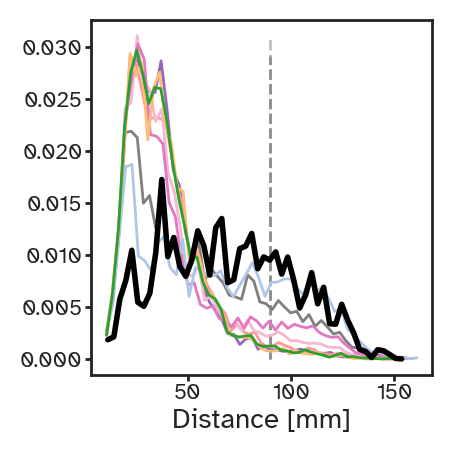

In [ ]:
    # import scipy.ndimage as ndimage

    # # plot degree distributions (smoothed) 
    # fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)), dpi=200)

    # max_value_for_line = 0 

    # for mode, distances in distributions_distances.items():
        
    #     if mode not in selected_methods and not mode == 'human': 
    #         continue
        
    #     # Create histogram to get counts
    #     number_bins = 50
    #     counts, bins = np.histogram(distances, bins=number_bins, density=True)
    #     bin_centers = (bins[:-1] + bins[1:]) / 2
        
    #     # Add padding to bin_centers (linear expansion)
    #     bin_centers = np.array([bins[0] - (bins[1]-bins[0])*i for i in range(20,0,-1)] + list(bin_centers) + 
    #                         [bins[-1] + (bins[1]-bins[0])*i for i in range(1,21)])

    #     # padded_counts = []
    #     # for count in counts: 
    #     count = np.array([0]*20 + list(counts) + [0]*20)
    #     count = ndimage.gaussian_filter1d(count, sigma=0.2) # 10) 
    #     #     padded_counts.append(count)

    #     if count.max() > max_value_for_line:
    #         max_value_for_line = count.max()
    #         ax.vlines(x=90, 
    #                 ymin=0, ymax=max_value_for_line, 
    #                 color="gray", 
    #                 linestyle='--', alpha=0.5)

    #     # # Smooth the histogram with Gaussian filter
    #     # # smoothed_counts = ndimage.gaussian_filter1d(padded_counts, sigma=10) # 2
        
    #         # Plot smoothed curve
    #     ax.plot(bin_centers[20:-20], 
    #             count[20:-20],
    #             label=method_names[mode] if mode != 'human' else 'Human Connectomes',
    #             color=metric_colors[mode] if mode != 'human' else 'black',
    #             linewidth=2 if mode == "human" else 1
    #             )

    # plt.xlabel('Distance [mm]')
    # plt.ylabel("")
    # # plt.legend(fontsize=8, bbox_to_anchor=(1, 1), frameon=False)
    # plt.tight_layout()
    # plt.savefig(output_path / "top20_networks_distance_distributions.pdf", bbox_inches="tight")
    # print(output_path / "top20_networks_distance_distributions.pdf")
    # plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/ground_truth_analysis/top20_networks_degree_distributions.pdf


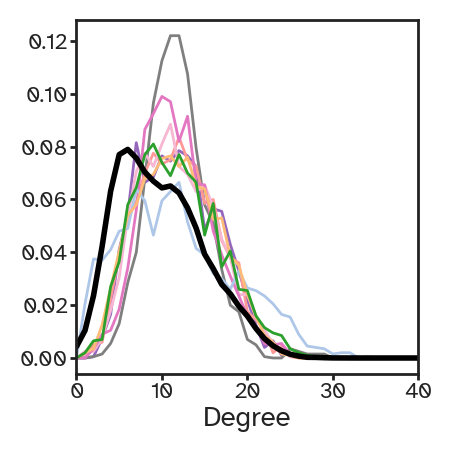

In [ ]:
    # import scipy.ndimage as ndimage

    # # plot degree distributions (smoothed) 
    # fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)), dpi=200)

    # for mode, degrees in distributions_degree.items():
        
    #     if mode not in selected_methods and not mode == 'human': 
    #         continue
        
    #     # Create bins that always have steps of one and start quantity 0
    #     max_degree = 100
    #     bins = np.arange(0, max_degree + 2, step=1) - 0.5  # bins of width 1 centered on integers
        
    #     # Create histogram to get counts
    #     counts, bins = np.histogram(degrees, bins=bins, density=True)
    #     bin_centers = (bins[:-1] + bins[1:]) / 2
        
    #     count = ndimage.gaussian_filter1d(counts, sigma=0.2) 
        
    #     # Plot smoothed curve
    #     ax.plot(bin_centers, 
    #             count,
    #             label=method_names[mode] if mode != 'human' else 'Human Connectomes',
    #             color=metric_colors[mode] if mode != 'human' else 'black',
    #             linewidth=1 if mode != 'human' else 2
    #             )

    # plt.xlim(0, 40)
        

    # plt.xlabel('Degree')
    # plt.ylabel("")
    # # plt.legend()
    # plt.tight_layout()
    # plt.savefig(output_path / "top20_networks_degree_distributions.pdf", bbox_inches="tight")
    # print(output_path / "top20_networks_degree_distributions.pdf")
    # plt.show()

# Degeneration

In [ ]:
# from typing import Dict, List

# # Base directory for your chaos analysis results
# base_dir = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis"
# output_dir = f"{base_dir}/plots"
# Path(output_dir).mkdir(parents=True, exist_ok=True)


# # degeneration_x_label_descriptor = "Degeneration Level\n(Consensus to Chaos)" # 'Step (0=Consensus -> Max=Chaos)'
# # degeneration_x_label_descriptor = "Degeneration: Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'
# degeneration_x_label_descriptor = "Increasing Degeneration" # : Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'



Plotting comparison...
Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_comparison_all_metrics.pdf


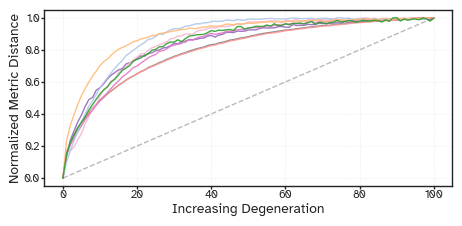

In [ ]:
# def plot_multiple_metrics_comparison(
#     csv_paths: Dict[str, str],
#     output_path: str = None,
#     figsize_cm: tuple = (20, 12),
#     normalize: bool = True
# ):
#     """
#     Compare multiple metrics on the same plot.
#     """
#     fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
#     for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
#         # Load data
#         df = pd.read_csv(csv_path)
        
#         # Calculate mean trajectory
#         df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
        
#         # Normalize if requested
#         if normalize:
#             min_val = df_summary['mean'].min()
#             max_val = df_summary['mean'].max()
#             if max_val > min_val:  # Avoid division by zero
#                 df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
#                 df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
#                 y_col = 'mean_norm'
#                 std_col = 'std_norm'
#             else:
#                 y_col = 'mean'
#                 std_col = 'std'
#         else:
#             y_col = 'mean'
#             std_col = 'std'
        
#         # Plot
#         color = metric_colors[metric_name]
#         ax.plot(
#             df_summary['step'],
#             df_summary[y_col],
#             color=color,
#             label=method_names[metric_name],
#             alpha=0.9
#         )

#         # print(method_names[metric_name])
#         # # Optional: add std band
#         # ax.fill_between(
#         #     df_summary['step'],
#         #     df_summary[y_col] - df_summary[std_col],
#         #     df_summary[y_col] + df_summary[std_col],
#         #     alpha=0.15,
#         #     color=color
#         # )
    
#     # Formatting
#     ax.set_xlabel(degeneration_x_label_descriptor)
#     if normalize:
#         ax.set_ylabel('Normalized Metric Distance') # , fontsize=11)
#     else:
#         ax.set_ylabel('Metric Distance')

#     # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
#     ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
#     # Add diagonal line for reference
#     max_x = df_summary['step'].max()
#     ax.plot([0, max_x], [0, 1], 'k--', alpha=0.3, linewidth=1)

#     # plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1,1))
#     plt.tight_layout()
    
#     if output_path:
#         plt.savefig(output_path, dpi=300, bbox_inches='tight')
#         print(f"Saved comparison plot to: {output_path}")
#     else:
#         plt.show()
    
    
#     # plt.close()
#     plt.show()
    
#     return fig, ax



# # Plot comparison of all metrics
# print("\nPlotting comparison...")
# csv_paths = {}
# for metric in selected_methods: 
#     csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
#     if Path(csv_path).exists():
#         csv_paths[metric] = csv_path

# if csv_paths:
#     plot_multiple_metrics_comparison(
#         csv_paths=csv_paths,
#         output_path=f"{output_dir}/chaos_comparison_all_metrics.pdf",
#         # figsize_cm=(6,6), # 
#         figsize_cm=(12,6), # 6),
#         normalize=True
#     )
    



Plotting comparison...
Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_comparison_all_metrics_square.pdf


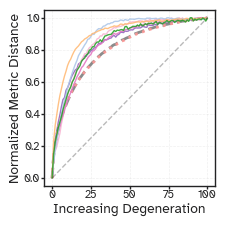

In [ ]:
# def plot_multiple_metrics_comparison(
#     csv_paths: Dict[str, str],
#     output_path: str = None,
#     figsize_cm: tuple = (20, 12),
#     normalize: bool = True
# ):
#     """
#     Compare multiple metrics on the same plot.
#     """
#     fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
#     for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
#         # Load data
#         df = pd.read_csv(csv_path)
        
#         # Calculate mean trajectory
#         df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
        
#         # Normalize if requested
#         if normalize:
#             min_val = df_summary['mean'].min()
#             max_val = df_summary['mean'].max()
#             if max_val > min_val:  # Avoid division by zero
#                 df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
#                 df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
#                 y_col = 'mean_norm'
#                 std_col = 'std_norm'
#             else:
#                 y_col = 'mean'
#                 std_col = 'std'
#         else:
#             y_col = 'mean'
#             std_col = 'std'

#         # Configs: line-thickness and style
#         line_thickness = 2 if (metric_name == 'delta_con' or metric_name == 'frobenius') else 1 # spectral_distance_adjacency
#         # linestyle = ':' if (metric_name == 'delta_con' or metric_name == 'frobenius') else '-'
#         linestyle = '-'
#         if metric_name == 'frobenius':
#             linestyle = ':'
#         elif metric_name == 'delta_con':
#             linestyle = '--'

#         # Plot
#         color = metric_colors[metric_name]
#         ax.plot(
#             df_summary['step'],
#             df_summary[y_col],
#             color=color,
#             label=method_names[metric_name],
#             alpha=0.9,
#             linewidth=line_thickness,
#             linestyle=linestyle
#         )

#         # print(method_names[metric_name])
#         # # Optional: add std band
#         # ax.fill_between(
#         #     df_summary['step'],
#         #     df_summary[y_col] - df_summary[std_col],
#         #     df_summary[y_col] + df_summary[std_col],
#         #     alpha=0.15,
#         #     color=color
#         # )
    
#     # Formatting
#     ax.set_xlabel(degeneration_x_label_descriptor)
#     if normalize:
#         ax.set_ylabel('Normalized Metric Distance') # , fontsize=11)
#     else:
#         ax.set_ylabel('Metric Distance')

#     # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
#     ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
#     # Add diagonal line for reference
#     max_x = df_summary['step'].max()
#     ax.plot([0, max_x], [0, 1], 'k--', alpha=0.3, linewidth=1)
    
    

#     # plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1,1))
#     plt.tight_layout()
    
#     if output_path:
#         plt.savefig(output_path, dpi=300, bbox_inches='tight')
#         print(f"Saved comparison plot to: {output_path}")
#     else:
#         plt.show()
    
    
#     # plt.close()
#     plt.show()
    
#     return fig, ax



# # Plot comparison of all metrics
# print("\nPlotting comparison...")
# csv_paths = {}
# for metric in selected_methods: 
#     csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
#     if Path(csv_path).exists():
#         csv_paths[metric] = csv_path

# if csv_paths:
#     plot_multiple_metrics_comparison(
#         csv_paths=csv_paths,
#         output_path=f"{output_dir}/chaos_comparison_all_metrics_square.pdf",
#         # figsize_cm=(6,6), # 
#         figsize_cm=(6,6), # 6),
#         normalize=True
#     )
    


# PCA 

In [ ]:
base_path

PosixPath('/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuration"
output_path = Path(base_path) / "method_evaluation"
output_path.mkdir(exist_ok=True)


def load_all_methods():
    """Load and combine all method data."""
    all_data_list = []
    loaded_methods = []
    
    for method in all_dist_measures:
        path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
        try:
            df = pd.read_csv(path)
            metric_cols = [col for col in df.columns 
                          if col not in ["eta", "gamma", "network_index", "filename", "id"]]
            if metric_cols:
                df['metric_value'] = df[metric_cols[0]]
                df['method'] = method
                all_data_list.append(df[['eta', 'gamma', 'id', 'metric_value', 'method']])
                loaded_methods.append(method)
                print(f"  ✓ Loaded {method}")
        except FileNotFoundError:
            print(f"  ✗ File not found for {method}")
    
    all_data = pd.concat(all_data_list, ignore_index=True)
    
    # Create wide format
    wide_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    return wide_data, loaded_methods


def normalize_methods(data, methods):
    """Normalize each method to [0, 1] range."""
    normalized = data.copy()
    for method in methods:
        min_val = data[method].min()
        max_val = data[method].max()
        if max_val > min_val:
            normalized[method] = (data[method] - min_val) / (max_val - min_val)
    return normalized


# ============================================================================
# STRATEGY 1: CONSENSUS-BASED APPROACHES
# ============================================================================

def consensus_approaches(data, methods):
    """Calculate different consensus measures."""
    print("\n" + "="*70)
    print("STRATEGY 1: CONSENSUS-BASED GROUND TRUTH")
    print("="*70)
    
    results = {}
    
    # Normalize first
    norm_data = normalize_methods(data, methods)
    
    # 1. Mean consensus (ensemble average)
    norm_data['consensus_mean'] = norm_data[methods].mean(axis=1)
    
    # 2. Median consensus (robust to outliers)
    norm_data['consensus_median'] = norm_data[methods].median(axis=1)
    
    # 3. Trimmed mean (remove top/bottom 10%)
    norm_data['consensus_trimmed'] = norm_data[methods].apply(
        lambda x: stats.trim_mean(x.dropna(), 0.1), axis=1
    )
    
    # Calculate correlations with each consensus
    for consensus_type in ['mean', 'median', 'trimmed']:
        col = f'consensus_{consensus_type}'
        print(f"\nCorrelations with {consensus_type.upper()} consensus:")
        corrs = {}
        for method in methods:
            corr = norm_data[method].corr(norm_data[col])
            corrs[method] = corr
            print(f"  {method:30s}: {corr:.4f}")
        results[consensus_type] = corrs
    
    # Save
    consensus_df = pd.DataFrame(results).T
    consensus_df.to_csv(output_path / 'consensus_correlations.csv')
    
    return norm_data, results


# ============================================================================
# STRATEGY 2: INTER-METHOD AGREEMENT
# ============================================================================

def inter_method_agreement(data, methods):
    """Calculate how well each method agrees with all others."""
    print("\n" + "="*70)
    print("STRATEGY 2: INTER-METHOD AGREEMENT")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    # Calculate average correlation with all other methods
    agreement_scores = {}
    for method1 in methods:
        corrs = []
        for method2 in methods:
            if method1 != method2:
                corr = norm_data[method1].corr(norm_data[method2])
                if not np.isnan(corr):
                    corrs.append(corr)
        agreement_scores[method1] = np.mean(corrs) if corrs else 0
    
    print("\nAverage agreement with other methods:")
    for method, score in sorted(agreement_scores.items(), key=lambda x: x[1], reverse=True):
        print(f"  {method:30s}: {score:.4f}")
    
    # Plot
    sorted_methods = sorted(agreement_scores.keys(), key=lambda x: agreement_scores[x], reverse=True)
    values = [agreement_scores[m] for m in sorted_methods]
    
    pd.DataFrame({'method': list(agreement_scores.keys()), 
                  'agreement_score': list(agreement_scores.values())}).to_csv(
        output_path / 'inter_method_agreement.csv', index=False)
    
    return agreement_scores


# ============================================================================
# STRATEGY 3: PCA-BASED APPROACH
# ============================================================================

def pca_approach(data, methods):
    """Use PCA to find the main component across methods."""
    print("\n" + "="*70)
    print("STRATEGY 3: PCA-BASED APPROACH")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    # Prepare data (remove NaNs)
    X = norm_data[methods].dropna()
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"\nExplained variance by component:")
    for i, var in enumerate(pca.explained_variance_ratio_[:5]):
        print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
    print(f"  Cumulative (first 3): {pca.explained_variance_ratio_[:3].sum():.4f}")
    
    # Loadings (how much each method contributes to PC1)
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(len(methods))],
        index=methods
    )
    
    print(f"\nPC1 Loadings (main component):")
    for method, loading in loadings['PC1'].abs().sort_values(ascending=False).items():
        print(f"  {method:30s}: {loadings.loc[method, 'PC1']:7.4f} (|{loading:.4f}|)")
    
    # Save
    loadings.to_csv(output_path / 'pca_loadings.csv')
    
    # Calculate correlation of each method with PC1
    pc1_scores = X_pca[:, 0]
    pc1_correlations = {}
    for i, method in enumerate(methods):
        pc1_correlations[method] = np.corrcoef(X[method], pc1_scores)[0, 1]
    
    return loadings, pca, pc1_correlations


# ============================================================================
# STRATEGY 4: COEFFICIENT OF VARIATION (STABILITY)
# ============================================================================

def stability_analysis(data, methods):
    """Analyze which methods have more stable/consistent values."""
    print("\n" + "="*70)
    print("STRATEGY 4: STABILITY ANALYSIS")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    stability_metrics = {}
    
    for method in methods:
        values = norm_data[method].dropna()
        stability_metrics[method] = {
            'cv': values.std() / values.mean() if values.mean() != 0 else np.inf,  # Coefficient of variation
            'iqr': values.quantile(0.75) - values.quantile(0.25),  # Interquartile range
            'range': values.max() - values.min(),
            'mad': np.median(np.abs(values - values.median()))  # Median absolute deviation
        }
    
    print("\nStability metrics (lower = more stable/consistent):")
    print("\nCoefficient of Variation (CV):")
    for method, metrics in sorted(stability_metrics.items(), key=lambda x: x[1]['cv']):
        print(f"  {method:30s}: {metrics['cv']:.4f}")
    
    pd.DataFrame(stability_metrics).T.to_csv(output_path / 'stability_metrics.csv')
    
    return stability_metrics


# ============================================================================
# SUMMARY REPORT
# ============================================================================

def create_summary_report(consensus_results, agreement_scores, pc1_correlations, stability_metrics):
    """Create a comprehensive summary ranking methods."""
    print("\n" + "="*70)
    print("COMPREHENSIVE SUMMARY")
    print("="*70)
    
    methods = list(agreement_scores.keys())
    
    summary = pd.DataFrame(index=methods)
    
    # Add consensus correlations
    summary['consensus_mean'] = [consensus_results['mean'][m] for m in methods]
    summary['consensus_median'] = [consensus_results['median'][m] for m in methods]
    
    # Add inter-method agreement
    summary['inter_method_agreement'] = [agreement_scores[m] for m in methods]
    
    # Add PC1 correlation (absolute value)
    summary['pc1_correlation'] = [abs(pc1_correlations[m]) for m in methods]
    
    # Add stability (inverse CV, so higher = better)
    summary['stability'] = [1 / (stability_metrics[m]['cv'] + 0.01) for m in methods]
    
    # Normalize all metrics to [0, 1]
    for col in summary.columns:
        min_val = summary[col].min()
        max_val = summary[col].max()
        if max_val > min_val:
            summary[col] = (summary[col] - min_val) / (max_val - min_val)
    
    # Calculate composite score (equal weighting)
    summary['composite_score'] = summary.mean(axis=1)
    
    # Rank
    summary['rank'] = summary['composite_score'].rank(ascending=False)
    
    # Sort by composite score
    summary = summary.sort_values('composite_score', ascending=False)
    
    print("\nFINAL RANKING (by composite score):")
    print(summary.to_string())
    
    summary.to_csv(output_path / 'method_ranking_summary.csv')
    
    return summary



# Load data
data, methods = load_all_methods()

# Run all strategies
agreement_scores = inter_method_agreement(data, methods)
loadings, pca_model, pc1_correlations = pca_approach(data, methods)
stability_metrics = stability_analysis(data, methods)


  ✓ Loaded resistance
  ✓ Loaded delta_con
  ✓ Loaded frobenius
  ✓ Loaded spectral_distance_adjacency
  ✓ Loaded netrd_non_backtracking_spectral
  ✓ Loaded energy
  ✓ Loaded portrait
  ✓ Loaded net_simile

STRATEGY 2: INTER-METHOD AGREEMENT

Average agreement with other methods:
  netrd_non_backtracking_spectral: 0.5312
  spectral_distance_adjacency   : 0.5129
  portrait                      : 0.4608
  net_simile                    : 0.4260
  frobenius                     : 0.3528
  energy                        : 0.3072
  resistance                    : 0.0473
  delta_con                     : -0.1446

STRATEGY 3: PCA-BASED APPROACH

Explained variance by component:
  PC1: 0.5624 (56.24%)
  PC2: 0.2485 (24.85%)
  PC3: 0.0890 (8.90%)
  PC4: 0.0493 (4.93%)
  PC5: 0.0205 (2.05%)
  Cumulative (first 3): 0.8999

PC1 Loadings (main component):
  portrait                      :  0.4471 (|0.4471|)
  spectral_distance_adjacency   :  0.4383 (|0.4383|)
  net_simile                    :  0.4359 

/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


  ✓ Loaded resistance
  ✓ Loaded delta_con
  ✓ Loaded frobenius
  ✓ Loaded spectral_distance_adjacency
  ✓ Loaded netrd_non_backtracking_spectral
  ✓ Loaded energy
  ✓ Loaded portrait
  ✓ Loaded net_simile


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/method_evaluation/pca_analysis_scree.pdf


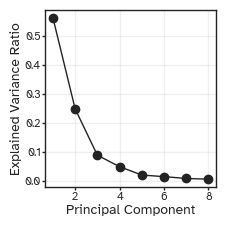

In [ ]:


# STRATEGY 3: PCA-BASED APPROACH
"""Use PCA to find the main component across methods."""

# Load data
data, methods = load_all_methods()
norm_data = normalize_methods(data, methods)

# Prepare data (remove NaNs)
X = norm_data[methods].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Loadings (how much each method contributes to PC1)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(methods))],
    index=methods
)

# Save
loadings.to_csv(output_path / 'pca_loadings.csv')

# Plot loadings
fig, ax = plt.subplots(1, 1, figsize=viz.cm_to_inch((6,6))) # (16, 6))

# PC1 loadings
sorted_methods = loadings['PC1'].abs().sort_values(ascending=False).index
values = [loadings.loc[m, 'PC1'] for m in sorted_methods]
colors = [halfblack for v in values] # '#10b981' if v > 0 else '#ef4444' for v in values]

sorted_methods_pc1 = sorted_methods.copy()


# Scree plot
ax.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
                pca.explained_variance_ratio_, 'o-', # linewidth=2, 
                # markersize=8, 
                color=halfblack) 
ax.set_xlabel('Principal Component') # , fontsize=11)
ax.set_ylabel('Explained Variance Ratio') # , fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'pca_analysis_scree.pdf', bbox_inches='tight')
print(output_path / 'pca_analysis_scree.pdf')
plt.show()

# Calculate correlation of each method with PC1
pc1_scores = X_pca[:, 0]
pc1_correlations = {}
for i, method in enumerate(methods):
    pc1_correlations[method] = np.corrcoef(X[method], pc1_scores)[0, 1]
    


  ✓ Loaded resistance
  ✓ Loaded delta_con
  ✓ Loaded frobenius
  ✓ Loaded spectral_distance_adjacency
  ✓ Loaded netrd_non_backtracking_spectral
  ✓ Loaded energy
  ✓ Loaded portrait
  ✓ Loaded net_simile
PC1 Loadings (Explains 56.2% of variance)
Index(['portrait', 'spectral_distance_adjacency', 'net_simile', 'energy',
       'netrd_non_backtracking_spectral', 'frobenius', 'delta_con',
       'resistance'],
      dtype='object')
PC2 Loadings (Explains 24.9% of variance)
['portrait', 'spectral_distance_adjacency', 'net_simile', 'energy', 'netrd_non_backtracking_spectral', 'frobenius', 'delta_con', 'resistance']
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/05_mst_animal_0/method_evaluation/pca_analysis_pc1_and_pc2.pdf


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


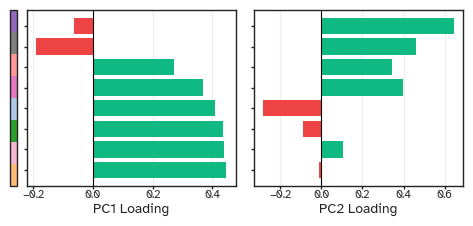

In [ ]:
# PCA 

# Load data
data, methods = load_all_methods()
norm_data = normalize_methods(data, methods)

# Prepare data (remove NaNs)
X = norm_data[methods].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Loadings (how much each method contributes to PC1)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(methods))],
    index=methods
)
loadings.to_csv(output_path / 'pca_loadings.csv')

# Plot loadings
fig, axes = plt.subplots(1, 2, figsize=viz.cm_to_inch((12,6))) # (16, 6))

# PC1 loadings
sorted_methods = loadings['PC1'].abs().sort_values(ascending=False).index
values = [loadings.loc[m, 'PC1'] for m in sorted_methods]
# colors = [halfblack for v in values] 
colors= ['#10b981' if v > 0 else '#ef4444' for v in values]

sorted_methods_pc1 = sorted_methods.copy()


# PC1 
axes[0].barh(range(len(sorted_methods)), values, color=colors) # , labels=sorted_methods)
axes[0].set_yticks(range(len(sorted_methods)))
# axes[0].set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
axes[0].set_xlabel('PC1 Loading') # , fontsize=11)
# axes[0].set_title(f'PC1 Loadings (Explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)') # , 
                    # fontsize=12, fontweight='bold')
print(f'PC1 Loadings (Explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)

axes[0].set_yticklabels([])

# PC2
print(sorted_methods)
values = [loadings.loc[m, 'PC2'] for m in sorted_methods]
# colors = [halfblack for v in values] # '#10b981' if v > 0 else '#ef4444' for v in values]#
colors= ['#10b981' if v > 0 else '#ef4444' for v in values]

axes[1].barh(range(len(sorted_methods)), values, color=colors) # , labels=sorted_methods)
axes[1].set_yticks(range(len(sorted_methods)))
# axes[0].set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
axes[1].set_xlabel('PC2 Loading') # , fontsize=11)
# axes[0].set_title(f'PC1 Loadings (Explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)') # , 
                    # fontsize=12, fontweight='bold')
print(f'PC2 Loadings (Explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

axes[1].set_yticklabels([])


plt.tight_layout()

# Get positions AFTER setting up the plot
heatmap_pos = axes[0].get_position()
highest_pos = heatmap_pos.y1
lowest_pos = heatmap_pos.y0
leftest_pos = heatmap_pos.x0
rightest_pos = heatmap_pos.x1

# Get positions AFTER setting up heatmap
heatmap_pos = axes[0].get_position()
highest_pos = heatmap_pos.y1
lowest_pos = heatmap_pos.y0
leftest_pos = heatmap_pos.x0
rightest_pos = heatmap_pos.x1

# Add left colorbar (method colors)
thickness_bars = 0.015 # 3
distance_between_bar_and_corr_heatmap = 0.02 # 0.03 for 6,6

print([m for m in sorted_methods])
# plt.cm.colors.ListedColormap(colors_for_legend)

colors_for_legend = [metric_colors[m] for m in sorted_methods] 
# cax = fig.add_axes([leftest_pos - thickness_bars - distance_between_bar_and_corr_heatmap -0.075, # 5, 
#                     lowest_pos +0.1, 
#                     thickness_bars, 
#                     highest_pos - lowest_pos - 0.05])
cax = fig.add_axes([leftest_pos - thickness_bars - distance_between_bar_and_corr_heatmap, #  -0.075, # 5, 
                    lowest_pos, #  +0.1, 
                    thickness_bars, 
                    highest_pos - lowest_pos]) #  - 0.05])
norm = plt.Normalize(vmin=0, vmax=len(all_methods_sorted_for_legend))
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks(ticks=[], labels=[])
cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')

plt.savefig(output_path / 'pca_analysis_pc1_and_pc2.pdf', bbox_inches='tight')
print(output_path / 'pca_analysis_pc1_and_pc2.pdf')
plt.show()

# Calculate correlation of each method with PC1
pc1_scores = X_pca[:, 0]
pc1_correlations = {}
for i, method in enumerate(methods):
    pc1_correlations[method] = np.corrcoef(X[method], pc1_scores)[0, 1]
    
